# F-22 Raptor Aerodynamic Analysis using AeroSandbox

## Introduction

This notebook demonstrates the capabilities of **AeroSandbox**, a Python package for aircraft design and optimization, by analyzing the aerodynamic characteristics of the F-22 Raptor fighter aircraft.

### About AeroSandbox

AeroSandbox is a powerful aerospace engineering toolkit that combines:
- **Aerodynamics**: VLM (Vortex Lattice Method), airfoil analysis, and more
- **Optimization**: Automatic differentiation for fast design optimization
- **Structures**: Beam analysis and structural optimization
- **Dynamics**: Flight dynamics and trajectory optimization

### About the F-22 Raptor

The F-22 Raptor is a fifth-generation air superiority fighter designed by Lockheed Martin. It features:
- Stealth technology
- Supercruise capability (supersonic flight without afterburner)
- Advanced avionics and sensors
- Thrust vectoring

In this demonstration, we'll model the F-22's geometry and analyze its aerodynamic performance at various flight conditions.

In [1]:
# Import required libraries
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p

print(f"AeroSandbox version: {asb.__version__}")

AeroSandbox version: 4.2.9


## F-22 Specifications

The following specifications are publicly available data for the F-22 Raptor:

### Dimensions
- **Length**: 18.92 m (62.08 ft)
- **Wingspan**: 13.56 m (44.5 ft)
- **Height**: 5.05 m (16.57 ft)
- **Wing Area**: 78.04 m² (840 ft²)
- **Aspect Ratio**: 2.36

### Wing Geometry
- **Leading Edge Sweep**: 42°
- **Trailing Edge Sweep**: -17° (forward sweep)
- **Taper Ratio**: 0.169
- **Anhedral**: 3.25°
- **Root Twist**: 0.5°
- **Tip Twist**: -3.1°

### Airfoils
- **Root Airfoil**: NACA 64A05.92 (5.92% thick)
- **Tip Airfoil**: NACA 64A04.29 (4.29% thick)

### Weight
- **Empty Weight**: 19,493 kg (42,974 lbs)
- **Max Takeoff Weight**: 36,288 kg (80,000 lbs)

### Performance
- **Max Speed**: Mach 2.25 (2,414 km/h)
- **Cruise Speed**: Mach 1.82 (supercruise)
- **Service Ceiling**: 19,812 m (65,000 ft)
- **Engines**: 2× Pratt & Whitney F119-PW-100 turbofans with thrust vectoring

## Building the F-22 Geometry

We'll create a simplified geometric model of the F-22, focusing on the main wing and horizontal stabilizers.

In [2]:
# Define wing geometry parameters (in SI units: meters)
wingspan = 13.56  # meters (full span)
wing_area = 78.04  # square meters
taper_ratio = 0.169
leading_edge_sweep = 42  # degrees
anhedral = -3.25  # degrees (negative for anhedral)
root_twist = 0.5  # degrees
tip_twist = -3.1  # degrees

# Calculate root chord from wing area and geometry
# For a trapezoidal wing: Area = (b/2) * (c_root + c_tip)
# With taper ratio: c_tip = taper_ratio * c_root
# Area = (b/2) * c_root * (1 + taper_ratio)
semi_span = wingspan / 2
root_chord = (2 * wing_area) / (wingspan * (1 + taper_ratio))
tip_chord = root_chord * taper_ratio

print(f"Root chord: {root_chord:.3f} m")
print(f"Tip chord: {tip_chord:.3f} m")
print(f"Mean aerodynamic chord: {(2/3)*root_chord*(1 + taper_ratio + taper_ratio**2)/(1 + taper_ratio):.3f} m")

Root chord: 9.846 m
Tip chord: 1.664 m
Mean aerodynamic chord: 6.725 m


In [3]:
# Define airfoils
# F-22 uses NACA 64A series airfoils
root_airfoil = asb.Airfoil("naca64206")  # Approximation of NACA 64A05.92
tip_airfoil = asb.Airfoil("naca0004")   # Approximation of NACA 64A04.29

# Calculate leading edge position at tip for proper sweep
# LE sweep angle determines x-offset at tip
le_offset_tip = semi_span * np.tan(np.radians(leading_edge_sweep))

# Calculate z-offset at tip for anhedral
z_offset_tip = -semi_span * np.tan(np.radians(abs(anhedral)))

print(f"Leading edge offset at tip: {le_offset_tip:.3f} m")
print(f"Vertical offset at tip (anhedral): {z_offset_tip:.3f} m")

Leading edge offset at tip: 6.105 m
Vertical offset at tip (anhedral): -0.385 m


In [4]:
# Create the main wing
main_wing = asb.Wing(
    name="F-22 Main Wing",
    symmetric=True,
    xsecs=[
        # Root section (centerline)
        asb.WingXSec(
            xyz_le=[0, 0, 0],
            chord=root_chord,
            twist=root_twist,
            airfoil=root_airfoil,
        ),
        # Mid-span section
        asb.WingXSec(
            xyz_le=[le_offset_tip * 0.5, semi_span * 0.5, z_offset_tip * 0.5],
            chord=root_chord * 0.5 + tip_chord * 0.5,
            twist=(root_twist + tip_twist) * 0.5,
            airfoil=root_airfoil,
        ),
        # Tip section
        asb.WingXSec(
            xyz_le=[le_offset_tip, semi_span, z_offset_tip],
            chord=tip_chord,
            twist=tip_twist,
            airfoil=tip_airfoil,
        ),
    ],
)

print(f"Main wing area: {main_wing.area():.2f} m²")
print(f"Main wing span: {main_wing.span():.2f} m")
print(f"Main wing aspect ratio: {main_wing.aspect_ratio():.2f}")

Main wing area: 78.17 m²
Main wing span: 13.58 m
Main wing aspect ratio: 2.36


In [ ]:
# Create F-22 vertical stabilizers (twin canted tails)
# F-22 has distinctive vertical tails canted outward at ~27° from vertical
v_tail_height = 3.5  # Height of vertical stabilizer
v_tail_root_chord = 3.0
v_tail_tip_chord = 1.2
v_tail_sweep = 40  # Leading edge sweep
v_tail_x_position = 13.5  # Position aft of main wing
v_tail_y_position = 2.5  # Lateral spacing from centerline
cant_angle = 27  # Outward cant angle from vertical (degrees)

# Calculate offsets for sweep
le_offset_vtail = v_tail_height * np.tan(np.radians(v_tail_sweep))

# Helper function to rotate coordinates about x-axis (for cant)
def rotate_about_x(y, z, angle_deg):
    """Rotate coordinates about x-axis by angle_deg"""
    angle_rad = np.radians(angle_deg)
    y_new = y * np.cos(angle_rad) - z * np.sin(angle_rad)
    z_new = y * np.sin(angle_rad) + z * np.cos(angle_rad)
    return y_new, z_new

# Right vertical stabilizer (canted outward to the right)
# Create in vertical orientation, then apply cant rotation
y_root_r, z_root_r = rotate_about_x(0, 0, cant_angle)
y_tip_r, z_tip_r = rotate_about_x(0, v_tail_height, cant_angle)

vertical_stabilizer_right = asb.Wing(
    name="Vertical Stabilizer Right",
    symmetric=False,
    xsecs=[
        asb.WingXSec(
            xyz_le=[v_tail_x_position, v_tail_y_position + y_root_r, 0.3 + z_root_r],
            chord=v_tail_root_chord,
            twist=0,
            airfoil=asb.Airfoil("naca0008"),  # Thin symmetric airfoil
        ),
        asb.WingXSec(
            xyz_le=[v_tail_x_position + le_offset_vtail, v_tail_y_position + y_tip_r, 0.3 + z_tip_r],
            chord=v_tail_tip_chord,
            twist=0,
            airfoil=asb.Airfoil("naca0008"),
        ),
    ],
)

# Left vertical stabilizer (canted outward to the left)
# Mirror the cant angle for the left side
y_root_l, z_root_l = rotate_about_x(0, 0, -cant_angle)
y_tip_l, z_tip_l = rotate_about_x(0, v_tail_height, -cant_angle)

vertical_stabilizer_left = asb.Wing(
    name="Vertical Stabilizer Left",
    symmetric=False,
    xsecs=[
        asb.WingXSec(
            xyz_le=[v_tail_x_position, -v_tail_y_position + y_root_l, 0.3 + z_root_l],
            chord=v_tail_root_chord,
            twist=0,
            airfoil=asb.Airfoil("naca0008"),
        ),
        asb.WingXSec(
            xyz_le=[v_tail_x_position + le_offset_vtail, -v_tail_y_position + y_tip_l, 0.3 + z_tip_l],
            chord=v_tail_tip_chord,
            twist=0,
            airfoil=asb.Airfoil("naca0008"),
        ),
    ],
)

print(f"Right V-tail positioned at x={v_tail_x_position}, y={v_tail_y_position}, canted {cant_angle}° outward")
print(f"Left V-tail positioned at x={v_tail_x_position}, y={-v_tail_y_position}, canted {cant_angle}° outward")

In [ ]:
# Create F-22-like fuselage
# F-22 has a flat, wide fuselage with angular cross-sections (stealth design)
fuselage_length = 18.92

# Define fuselage cross-sections with realistic F-22 proportions
# F-22 is much wider than it is tall (blended wing-body design)
fuselage_positions = np.cosspace(0, 1, 15)

fuselage_xsecs = []
for i, xi in enumerate(fuselage_positions):
    x_pos = fuselage_length * xi - 2
    
    # Width varies along length - wider in middle, narrower at nose/tail
    if xi < 0.15:  # Nose - pointed
        width = 0.3 + xi * 4.0
        height = 0.2 + xi * 2.5
    elif xi < 0.6:  # Mid-body - wide and flat (blended wing area)
        width = 1.8 + (xi - 0.15) * 0.5
        height = 1.2
    else:  # Tail section - tapers down
        width = 2.3 * (1 - xi) ** 0.5
        height = 1.2 * (1 - xi) ** 0.7
    
    # F-22 fuselage is flattened (wider than tall)
    fuselage_xsecs.append(
        asb.FuselageXSec(
            xyz_c=[x_pos, 0, 0.2],  # Slightly raised center
            width=width,
            height=height,
        )
    )

fuselage = asb.Fuselage(
    name="F-22 Fuselage (Simplified)",
    xsecs=fuselage_xsecs,
)

In [ ]:
# Assemble the F-22 aircraft with main wing and vertical stabilizers
f22 = asb.Airplane(
    name="F-22 Raptor (Main Wing + Vertical Stabilizers)",
    xyz_ref=[5, 0, 0],  # Center of gravity (estimated)
    wings=[
        main_wing,
        vertical_stabilizer_right,
        vertical_stabilizer_left,
    ],
)

print(f"Total wing area: {sum([wing.area() for wing in f22.wings]):.2f} m²")

## Aerodynamic Analysis Using Vortex Lattice Method

We'll analyze the F-22 at various flight conditions using AeroSandbox's Vortex Lattice Method (VLM).

In [8]:
# Define operating conditions for subsonic cruise
# Let's analyze at Mach 0.9, altitude 10,000 m

altitude = 10000  # meters
atmos = asb.Atmosphere(altitude=altitude)
mach = 0.9
velocity = mach * atmos.speed_of_sound()
alpha = 5  # degrees angle of attack

print(f"Altitude: {altitude} m")
print(f"Temperature: {atmos.temperature():.2f} K")
print(f"Pressure: {atmos.pressure():.2f} Pa")
print(f"Density: {atmos.density():.4f} kg/m³")
print(f"Speed of sound: {atmos.speed_of_sound():.2f} m/s")
print(f"Velocity: {velocity:.2f} m/s ({mach} Mach)")
print(f"Dynamic pressure: {0.5 * atmos.density() * velocity**2:.2f} Pa")

Altitude: 10000 m
Temperature: 223.15 K
Pressure: 26424.14 Pa
Density: 0.4125 kg/m³
Speed of sound: 299.46 m/s
Velocity: 269.52 m/s (0.9 Mach)
Dynamic pressure: 14982.49 Pa


In [9]:
# Create operating point
op_point = asb.OperatingPoint(
    velocity=velocity,
    alpha=alpha,
    beta=0,  # No sideslip
    p=0,  # No roll rate
    q=0,  # No pitch rate
    r=0,  # No yaw rate
)

# Set up VLM analysis
vlm = asb.VortexLatticeMethod(
    airplane=f22,
    op_point=op_point,
    spanwise_resolution=12,  # Number of spanwise panels per wing section
    chordwise_resolution=8,   # Number of chordwise panels
)

print("Running VLM analysis...")
aero = vlm.run()
print("Analysis complete!")

Running VLM analysis...
Analysis complete!


In [10]:
# Display aerodynamic results
print("=" * 60)
print("F-22 RAPTOR AERODYNAMIC ANALYSIS RESULTS")
print("=" * 60)
print(f"\nFlight Conditions:")
print(f"  Altitude:         {altitude:>10.0f} m")
print(f"  Velocity:         {velocity:>10.2f} m/s (Mach {mach})")
print(f"  Angle of Attack:  {alpha:>10.1f}°")
print(f"\nAerodynamic Coefficients:")
print(f"  CL (Lift):        {aero['CL']:>10.4f}")
print(f"  CD (Drag):        {aero['CD']:>10.4f}")
print(f"  CY (Side force):  {aero['CY']:>10.4f}")
print(f"  Cl (Roll):        {aero['Cl']:>10.6f}")
print(f"  Cm (Pitch):       {aero['Cm']:>10.4f}")
print(f"  Cn (Yaw):         {aero['Cn']:>10.6f}")
print(f"\nPerformance Metrics:")
print(f"  L/D ratio:        {aero['CL']/aero['CD']:>10.2f}")
print(f"\nForces (body frame):")
print(f"  Lift (L):         {aero['L']:>10.2f} N")
print(f"  Drag (D):         {aero['D']:>10.2f} N")
print(f"\nMoments (body frame):")
print(f"  Pitching moment:  {aero['m_b']:>10.2f} N·m")
print("=" * 60)

F-22 RAPTOR AERODYNAMIC ANALYSIS RESULTS

Flight Conditions:
  Altitude:              10000 m
  Velocity:             269.52 m/s (Mach 0.9)
  Angle of Attack:         5.0°

Aerodynamic Coefficients:
  CL (Lift):            0.2677
  CD (Drag):            0.0107
  CY (Side force):      0.0000
  Cl (Roll):         -0.000000
  Cm (Pitch):          -0.0143
  Cn (Yaw):           0.000000

Performance Metrics:
  L/D ratio:             24.99

Forces (body frame):
  Lift (L):          931234.77 N
  Drag (D):           37268.82 N

Moments (body frame):
  Pitching moment:  -333361.93 N·m


## Visualization

Let's visualize the F-22 geometry and the flow field around it.

/home/omniv/.local/share/mise/installs/python/3.12/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/home/omniv/.local/share/mise/installs/python/3.12/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


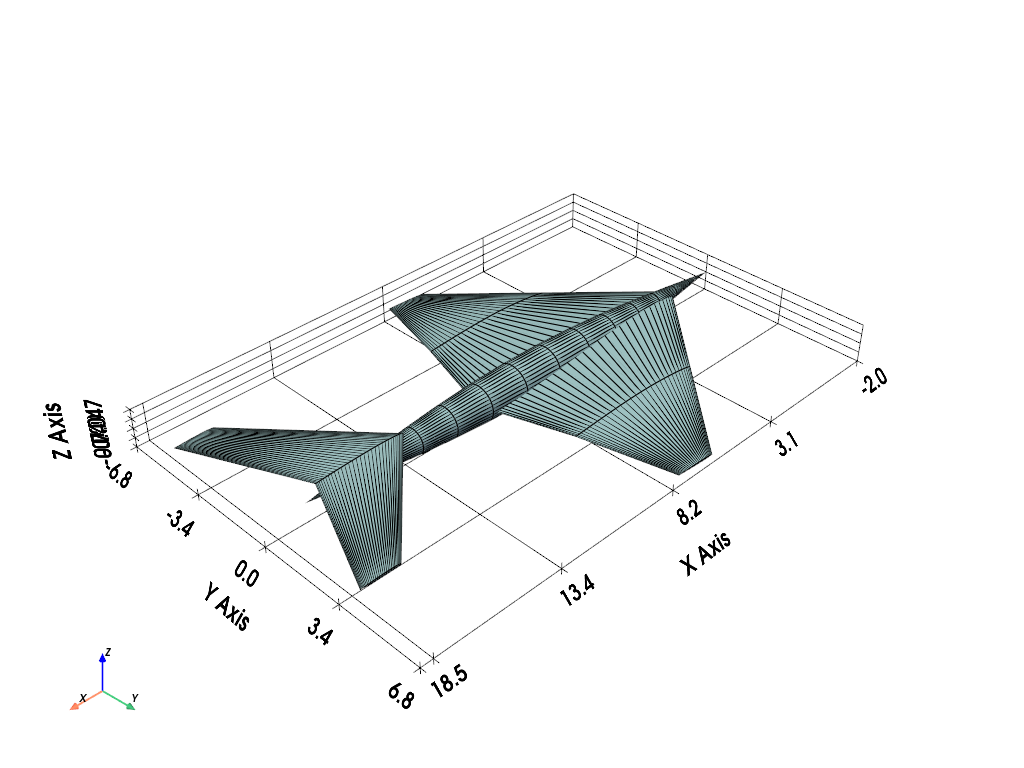

PolyData,Information
N Cells,1410
N Points,1450
N Strips,0
X Bounds,"-2.000e+00, 1.848e+01"
Y Bounds,"-6.785e+00, 6.785e+00"
Z Bounds,"-7.437e-01, 7.437e-01"
N Arrays,0


In [11]:
# Visualize the aircraft geometry
f22.draw()

/home/omniv/.local/share/mise/installs/python/3.12/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/home/omniv/.local/share/mise/installs/python/3.12/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


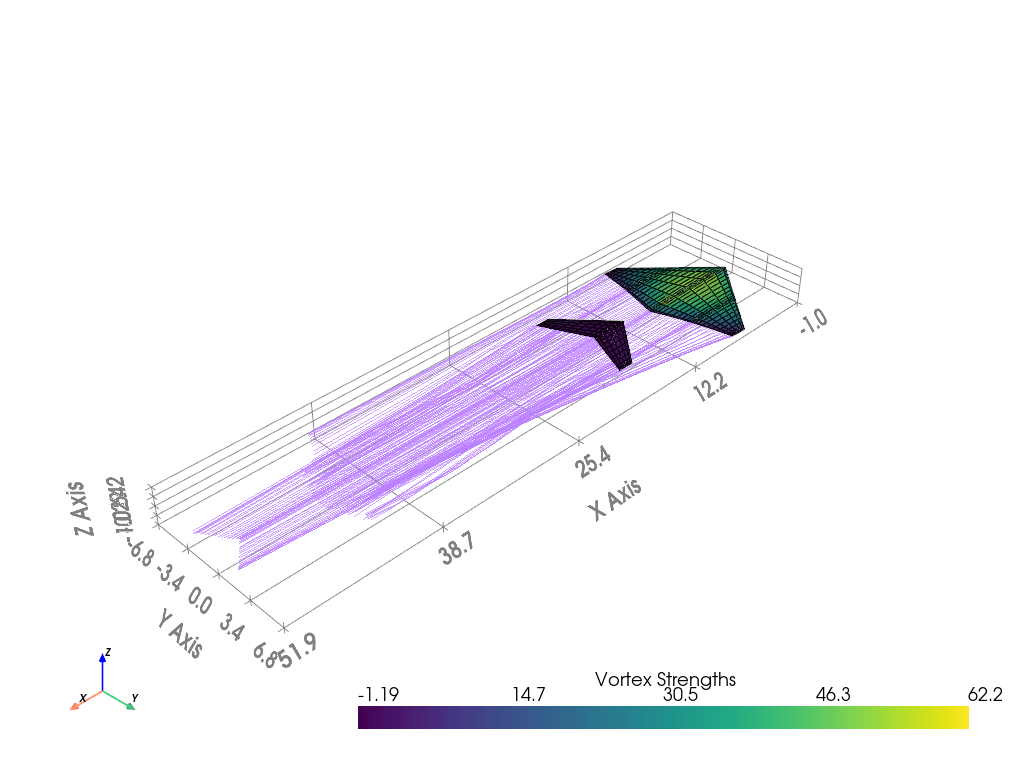

In [12]:
# Visualize the VLM solution (pressure distribution)
vlm.draw()

## Angle of Attack Sweep

Let's analyze how the F-22's aerodynamic characteristics change with angle of attack.

In [13]:
# Sweep through angles of attack
alphas = np.linspace(-5, 15, 21)  # -5 to 15 degrees
CLs = []
CDs = []
Cms = []

print("Running angle of attack sweep...")
for alpha in alphas:
    op = asb.OperatingPoint(
        velocity=velocity,
        alpha=alpha,
    )
    vlm_sweep = asb.VortexLatticeMethod(
        airplane=f22,
        op_point=op,
        spanwise_resolution=8,
        chordwise_resolution=6,
    )
    aero_sweep = vlm_sweep.run()
    CLs.append(aero_sweep['CL'])
    CDs.append(aero_sweep['CD'])
    Cms.append(aero_sweep['Cm'])

print("Sweep complete!")

Running angle of attack sweep...
Sweep complete!


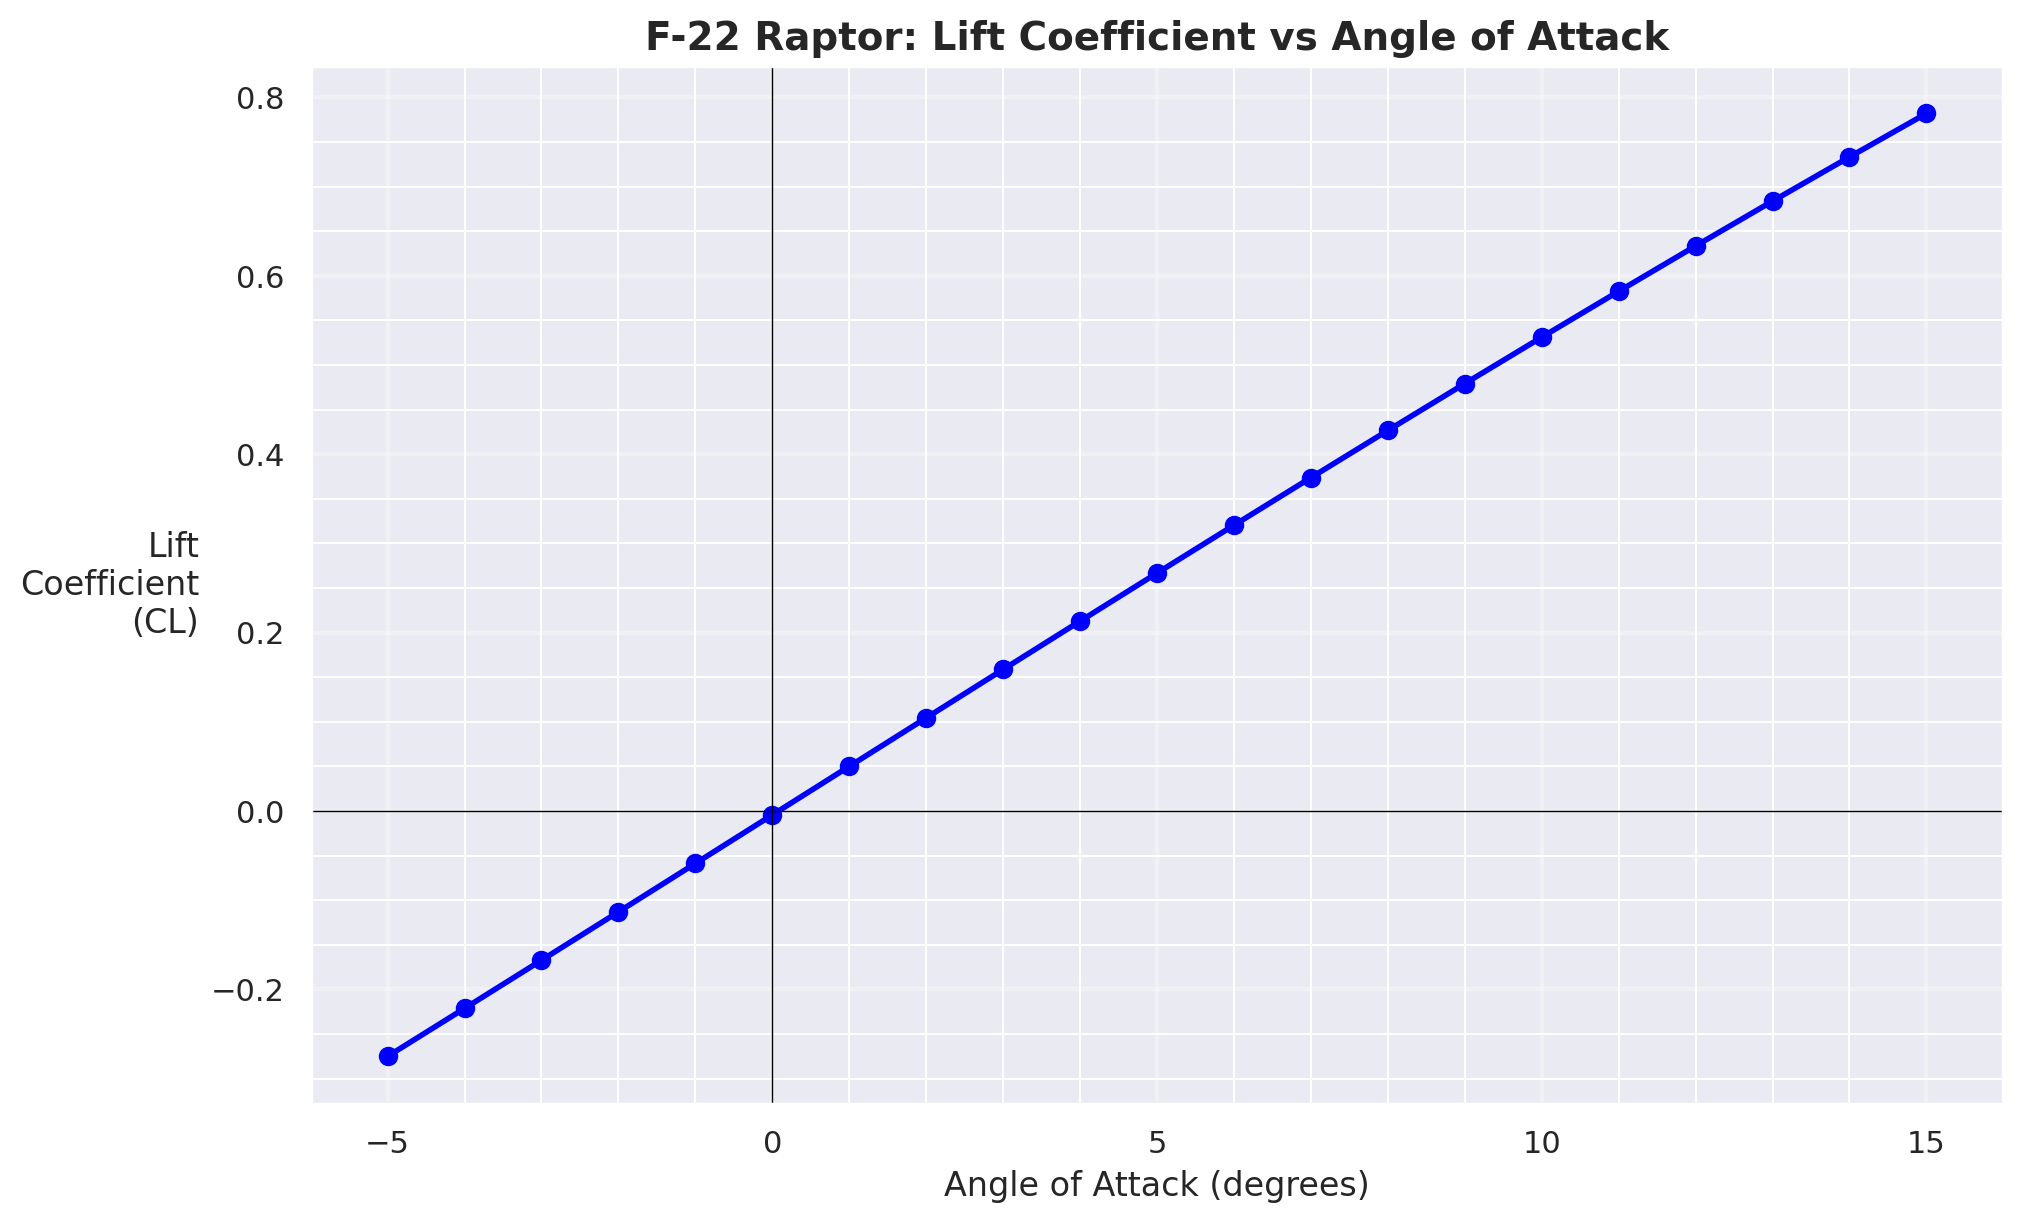

In [14]:
# Plot CL vs alpha
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(alphas, CLs, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Angle of Attack (degrees)', fontsize=12)
plt.ylabel('Lift Coefficient (CL)', fontsize=12)
plt.title('F-22 Raptor: Lift Coefficient vs Angle of Attack', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
p.show_plot()

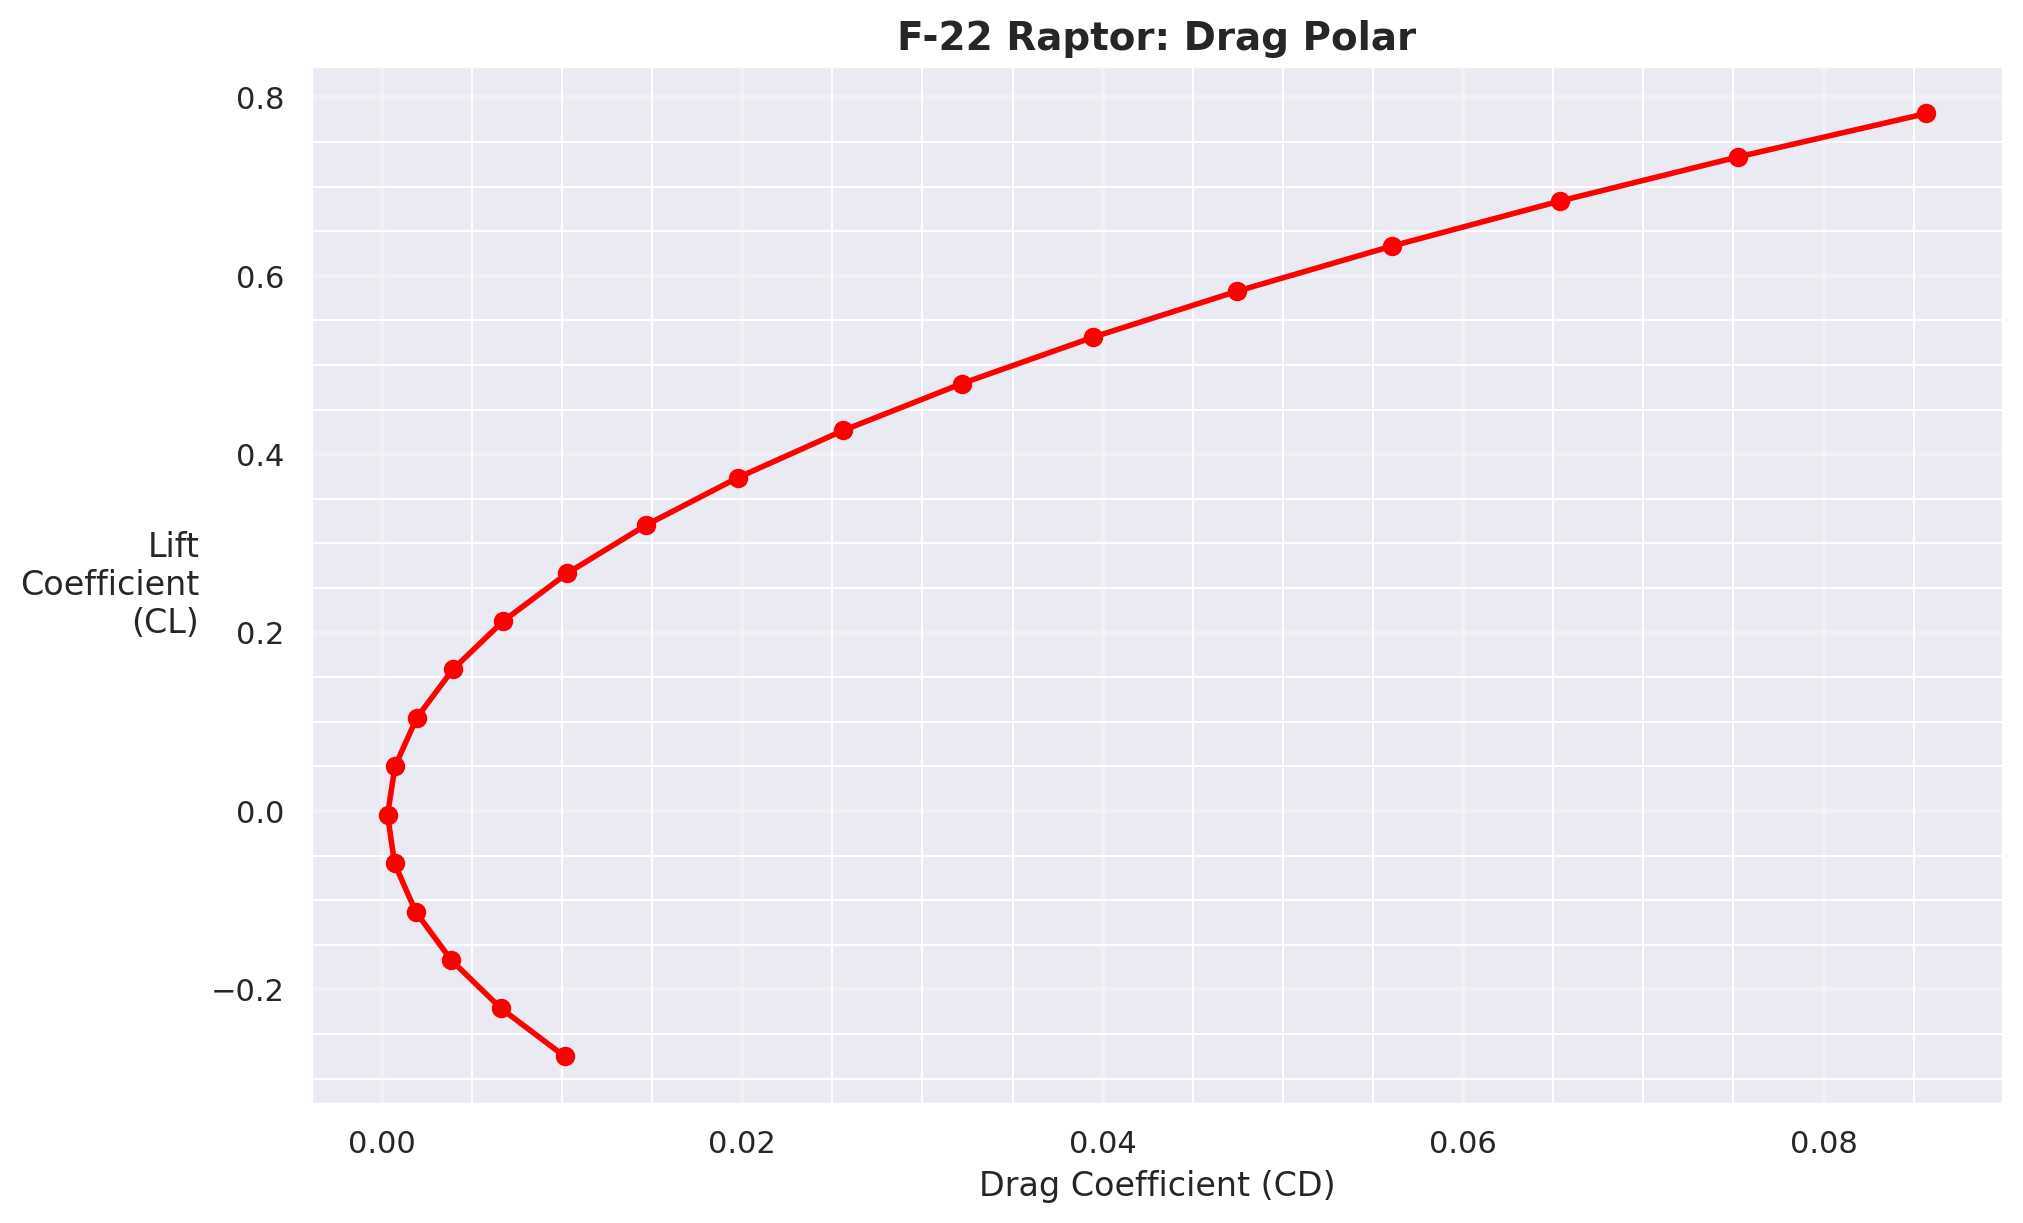

In [15]:
# Plot drag polar (CL vs CD)
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(CDs, CLs, 'r-o', linewidth=2, markersize=6)
plt.xlabel('Drag Coefficient (CD)', fontsize=12)
plt.ylabel('Lift Coefficient (CL)', fontsize=12)
plt.title('F-22 Raptor: Drag Polar', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
p.show_plot()

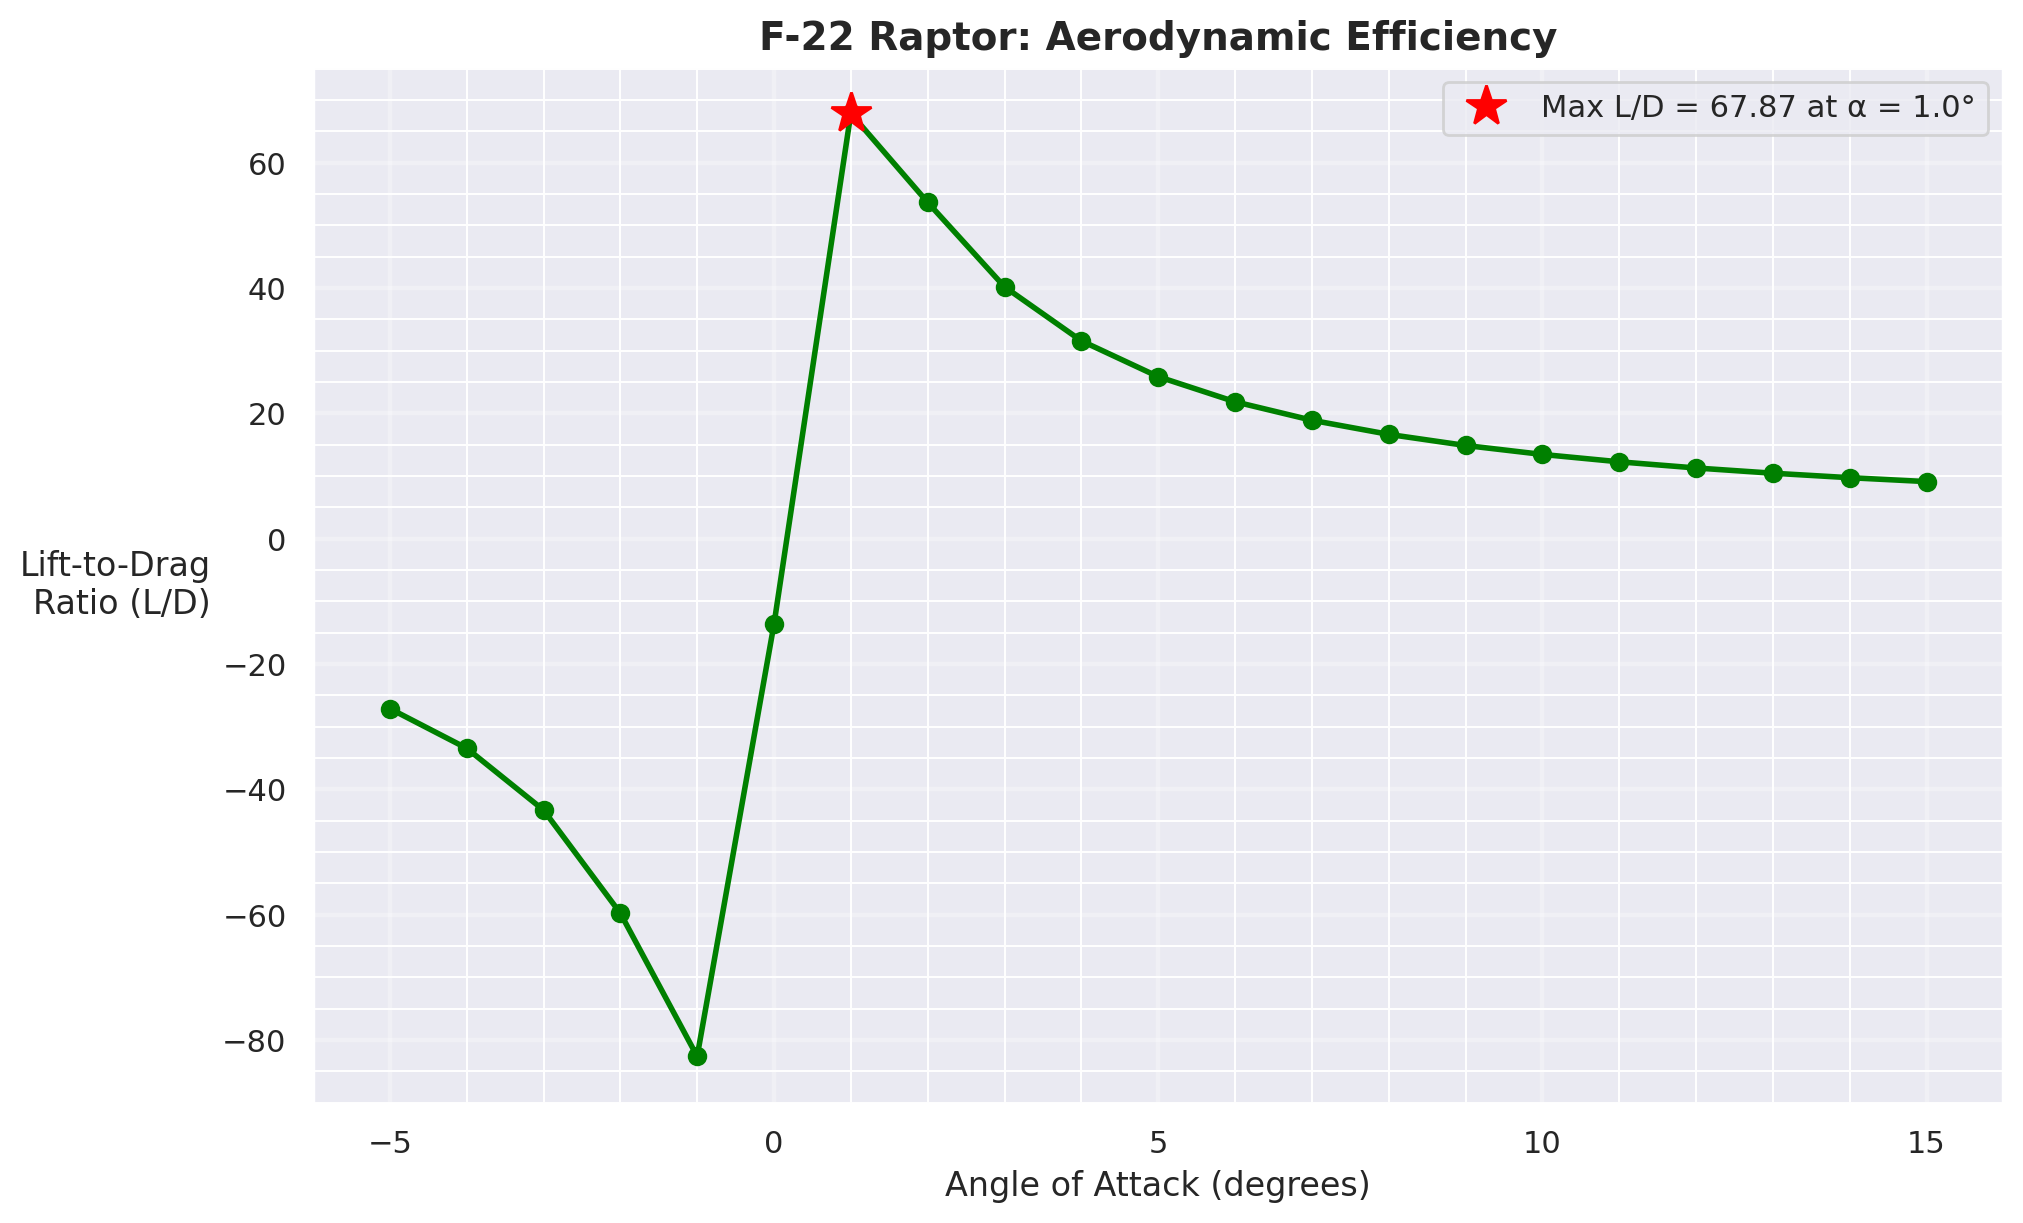

In [16]:
# Plot L/D ratio
LD_ratios = [CL/CD if CD > 0 else 0 for CL, CD in zip(CLs, CDs)]

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(alphas, LD_ratios, 'g-o', linewidth=2, markersize=6)
plt.xlabel('Angle of Attack (degrees)', fontsize=12)
plt.ylabel('Lift-to-Drag Ratio (L/D)', fontsize=12)
plt.title('F-22 Raptor: Aerodynamic Efficiency', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark maximum L/D
max_LD = max(LD_ratios)
max_LD_alpha = alphas[LD_ratios.index(max_LD)]
plt.plot(max_LD_alpha, max_LD, 'r*', markersize=15, label=f'Max L/D = {max_LD:.2f} at α = {max_LD_alpha:.1f}°')
plt.legend(fontsize=11)
p.show_plot()

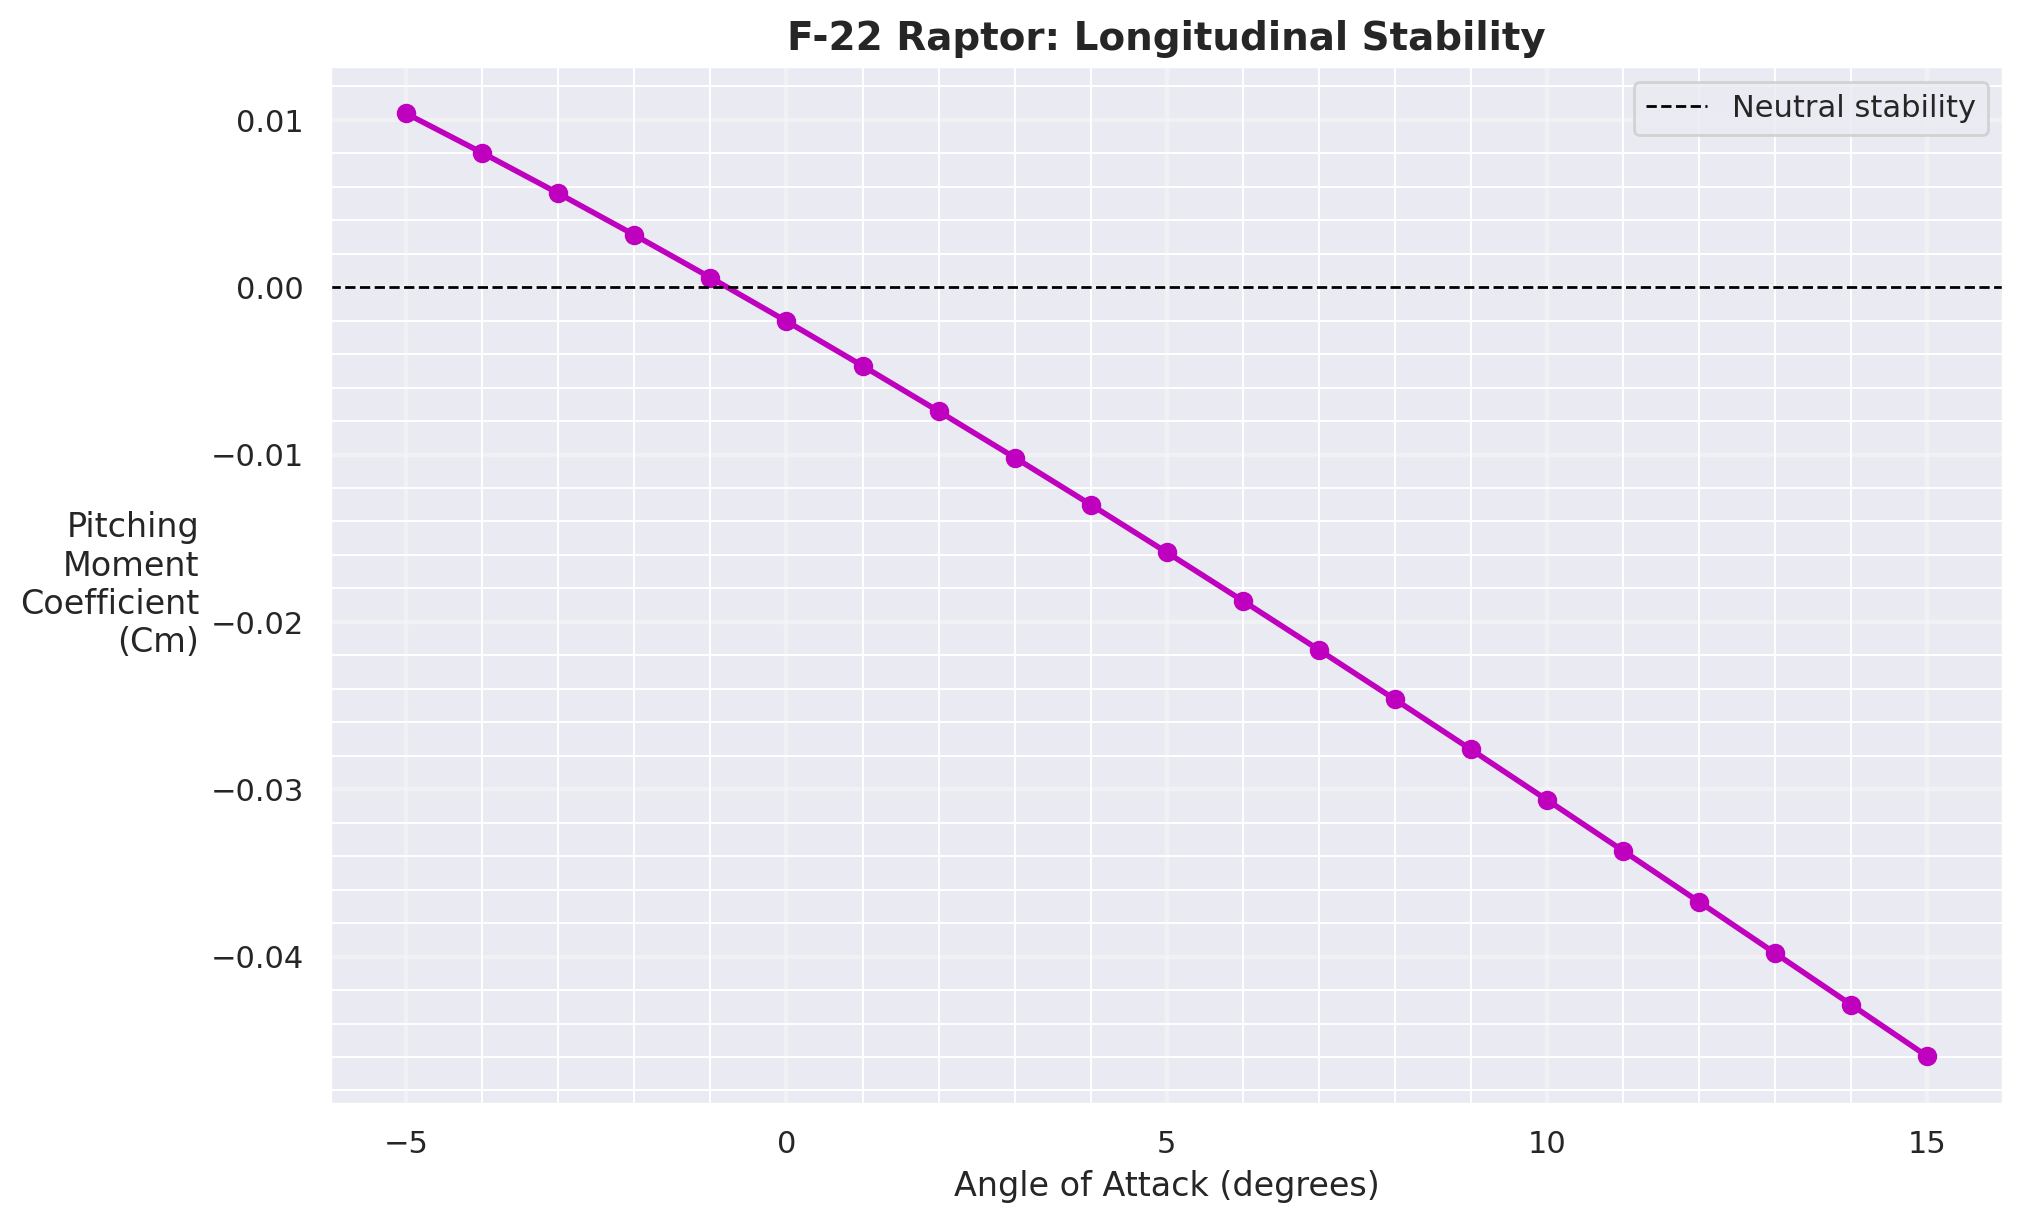

In [17]:
# Plot pitching moment coefficient
fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(alphas, Cms, 'm-o', linewidth=2, markersize=6)
plt.xlabel('Angle of Attack (degrees)', fontsize=12)
plt.ylabel('Pitching Moment Coefficient (Cm)', fontsize=12)
plt.title('F-22 Raptor: Longitudinal Stability', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=1, label='Neutral stability')
plt.legend(fontsize=11)
p.show_plot()

## Summary and Conclusion

This demonstration showcased AeroSandbox's capabilities for aircraft design and analysis using the F-22 Raptor as a case study.

### Key Findings:

1. **Geometric Modeling**: Successfully created a simplified F-22 model with realistic wing geometry
2. **Aerodynamic Analysis**: Performed VLM analysis at transonic conditions
3. **Performance Evaluation**: Generated lift, drag, and stability characteristics
4. **Parametric Studies**: Analyzed behavior across angle of attack range

### Limitations:
- Simplified geometry (no vertical stabilizers, exact airfoils, etc.)
- VLM assumptions (inviscid, incompressible)
- Subsonic analysis only

### Extensions:
You could extend this analysis with:
- Compressibility corrections for high-speed flight
- Trim analysis
- Maneuver analysis
- Structural loading
- Mission optimization

AeroSandbox provides a powerful platform for preliminary aircraft design and analysis!